In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import string
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.diagnostics import (
    avg_windows,
    R_hat
)

from flonacomldft.utils.io_utils import (
    get_project_path,
    get_path
)

import matplotlib as mlp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.transforms import Bbox
import seaborn as sns
import cmocean.cm as cmo

from flonacomldft.utils.plots import (
    load_ag6_image
)

In [3]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.05,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. NP', 'ab-flowMC', 'MD', 
                        'ab-flowMM w.o. NP', 'ab-flowMM'],
                        ['#0077BB', '#CC3311', '#cdb332',
                        '#0077BB', '#CC3311']))

sns.color_palette(methods_color.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667)]

# Figure 1

In [21]:
def set_plot_figure_1(
    cvs,
    density_samples,
    accs,
    rhat,
    energies,
    np_predictions,
    isomer,
    colors,
    figsize=(5.5*3, 2*3),
    fontsize=14,
    size_axes_label=14,
    size_tick_label=14,
    size_legend=11,
    linewidth=2,
    markersize=5,
    hspace=0.2,
    wspace=0.4,
):
    
    ncols = 4
    nrows = 2

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_legend,
                        }) 

    # -- set figure --

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=figsize,
                    gridspec_kw={'wspace': wspace,
                                'hspace': hspace})

    # -- set subplots --

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    ax1 = axs[0][2]
    ax2 = axs[0][3]
    ax3 = axs[1][2]
    ax4 = axs[1][3]

    l, b, h, w = axbig.get_position().get_points().flatten()
    axsmall = fig.add_axes([l*0.9, b, h*0.3, w*0.3])

    # -- subplot sharing axis --

    ax3.sharex(ax1)
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax4.sharex(ax2)
    plt.setp(ax2.get_xticklabels(), visible=False)

    # -- item to subplot and delete top and right axis lines --

    posx = -0.05
    posy = 1.05

    for n, ax in enumerate([axbig, ax1, ax2, ax3, ax4]):
        if n==0:
            disp = 0.025
        else:
            disp = 0
        ax.text(posx+disp,
        posy-disp, 
        string.ascii_uppercase[n], 
        transform=ax.transAxes, 
        weight='bold')

        ax.spines[['right', 'top']].set_visible(False)

    
    axsmall.set_axis_off()
        
    # -- plot isomer image --
    
    axsmall.imshow(load_ag6_image(isomer))

    # -- plot cvs (density) --
    
    sns.kdeplot(
        data=cvs[cvs['Method'] == cvs['Method'].unique()[0]], 
        x='CV1', 
        y='CV2',
        hue='Method',
        fill=False, 
        common_norm=False,
        #cmap=cmo.tempo_r,
        linewidths=linewidth*1.1,
        linestyles='--',
        ax=axbig,
        levels=6,
        )

    # -- plot cvs (samples) -- 

    sns.scatterplot(
            data=cvs[cvs['Method'] != cvs['Method'].unique()[0]],
            x='CV1', 
            y='CV2', 
            hue='Method',
            style='Method',
            ax=axbig,
            palette=colors,
            s=markersize*10,
            zorder=1,
            markers='o',
            #markers=['o', 's', '^'],
            alpha=1,
            legend=True,
        )
    
    patches = [ axbig.plot([],[], 
                               marker='o',  
                               markersize=markersize*2, 
                               color=colors[key], 
                label="{:s}".format(key) )[0]  for key in cvs['Method'].unique()[:3] ]
    
    axbig.legend(handles=patches)

    # -- plot accs --

    accs_avg = pd.DataFrame(columns=accs.columns)
    for col in accs.columns:
        accs_avg[col] = avg_windows(accs[col], window_size=40, axis=1)

    sns.lineplot(accs,
            alpha=0.1,
            palette=colors,
            linewidth=linewidth*0.5,
            linestyle='-',
            ax=ax1,
            legend=False,
            )

    sns.lineplot(accs_avg,
            alpha=1,
            palette=colors,
            linewidth=linewidth,
            linestyle='-',
            ax=ax1,
            legend=False,
            )

    ax1.set_ylabel("Acceptance ratio")

    # -- plot rhat --

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']

    for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            sns.lineplot(x=rhat[key][1], 
                        y=rhat[key][0][:, i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=rhat[key][2][i],
                        ax=ax3,
                        legend=False)
    
    ax3.axhline(1, c='k', ls='--', 
                  linewidth=linewidth)
    ax3.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax3.set_xlabel('Steps')
    ax3.set_ylabel(r'$\hat{R}$')

    # -- plot rhat legend --

    patches = [ ax3.plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth, 
                               markersize=markersize, 
                               color='black', 
                label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
    
    patches = patches + [ ax3.plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Threshold') )[0] ]
    
    ax3.legend(handles=patches)

    # -- plot energies --

    sns.histplot(data=energies,
                stat='density',
                x='Potential energy',
                hue='Method',
                bins=20,
                alpha=1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                fill=False,
                ax=ax2, 
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    ax2.set_ylabel('Density (u.a.)')

    # -- plot NP predictions --

    energy_max = energies.max().values[0]
    np_predictions = np_predictions[np_predictions['True values'] < energy_max]  

    np_predictions = np_predictions.sample(750).sort_values(by='Dataset label', ascending=False)

    palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']
                                    ))
    points = {'x': np.array([np_predictions['True values'].min(),
                  energy_max]),
            'y': np.array([np_predictions['True values'].min(), 
                  energy_max])}
    
    sns.lineplot(points,
                x='x',
                y='y',
                linestyle='--',
                color='k',
                linewidth=linewidth,
                ax=ax4,)

    sns.scatterplot(data=np_predictions,
                x='True values',
                y='Predict values',
                hue='Dataset label',
                style='Dataset label',
                markers=['p', 'X'],
                palette=palette_predictions,
                s=markersize*10,
                zorder=2.5,
                ax=ax4)

    handles, labels = ax4.get_legend_handles_labels()
    ax4.legend(handles=handles, labels=['Train', 'Test'])

    ax4.set_xlabel('Potential energy (eV)')
    ax4.set_ylabel('Predicted values (eV)')

    # -- plot legend outside --

    #handles, labels = axbig.get_legend_handles_labels()
    #
    #fig.legend(handles, labels, loc='upper center', 
    #        bbox_to_anchor=(0.5, 0.05),
    #        ncol=3, 
    #        fancybox=True, 
    #        shadow=True, 
    #        markerscale=markersize/2,
    #        fontsize=fontsize)
#
    #axbig.get_legend().remove()

    # -- set formatter axis --
 
    axbig.xaxis.set_major_locator(plt.MaxNLocator(4))
    axbig.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    axbig.yaxis.set_major_locator(plt.MaxNLocator(4))
    axbig.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax2.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

    ax3.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax4.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    

In [5]:
def random_selection(cvs_energies_df, N=1000):
    dfs = []
    methods = cvs_energies_df['Method'].unique()
    
    for method in methods:
        cvs_energies_df_method = cvs_energies_df[cvs_energies_df['Method']==method]
        idx_rand = torch.randint(0, 
                                cvs_energies_df_method.shape[0], 
                                (N,))
        cvs_energies_df_method = cvs_energies_df_method.iloc[idx_rand]
        dfs.append(cvs_energies_df_method)

    return pd.concat(dfs, ignore_index=True)

In [6]:
torch.manual_seed(30)

In [7]:
database_path = get_path() + '/andersen/datasets'
project_path = get_project_path()
data_path = 'data_for_plots'
path_to_save_figures = get_project_path() + '/figures/'

In [8]:
is_md = {i: pd.read_csv( database_path + '/is{:d}_flow_train.csv'.format(i) 
                        )[['C', 'R', 'potential_energy']] for i in range(2)}

cvs_energy_md = {}

for i in is_md.keys():
    cvs_energy_md[i] = pd.DataFrame(columns=['Method', 'CV1', 'CV2', 'Potential energy'])
    cvs_energy_md[i]['CV1'] = is_md[i]['C']
    cvs_energy_md[i]['CV2'] = is_md[i]['R']
    cvs_energy_md[i]['Potential energy'] = is_md[i]['potential_energy']
    cvs_energy_md[i]['Method']='MD'

In [9]:
cvs_energy_is = {i: pd.concat([ pd.read_csv(
    project_path + '/' + data_path + '/cvs_energy_ab-flowMC_is{:d}.csv'.format(i)
                ), cvs_energy_md[i]], ignore_index=True) for i in cvs_energy_md.keys()}

In [10]:
flowMC_methods = ['ab-flowMC w.o. NP', 'ab-flowMC']

rhats_is = {}

for i in cvs_energy_is.keys():
    
    rhats_is[i] = {}

    for method in flowMC_methods:
        
        cvs = cvs_energy_is[i][ cvs_energy_is[i]['Method'] == method
                            ][['CV1', 'CV2', 'Potential energy']].to_numpy().reshape(600, 50, 3)

        rhat = R_hat(cvs.transpose(1, 0, 2), labels=['CV1', 'CV2', 'Potential energy'])
        rhats_is[i][method] = rhat

In [11]:
cvs_energy_is_rand = {i: random_selection(cvs_energy_is[i], 1000) for i in cvs_energy_is.keys()}
density_samples_is = {i: pd.read_csv(project_path + '/' + data_path + '/density_samples_ab-flowMC_is{:d}.csv'.format(i)) for i in cvs_energy_is.keys()}
accs_is = {i: pd.read_csv(project_path + '/' + data_path + '/accs_ab-flowMC_is{:d}.csv'.format(i)) for i in cvs_energy_is.keys()}
np_predictions ={i: pd.read_csv(project_path + '/' + data_path + '/mlps_datasets_ab-flowMC_is{:d}.csv'.format(i)) for i in cvs_energy_is.keys()}

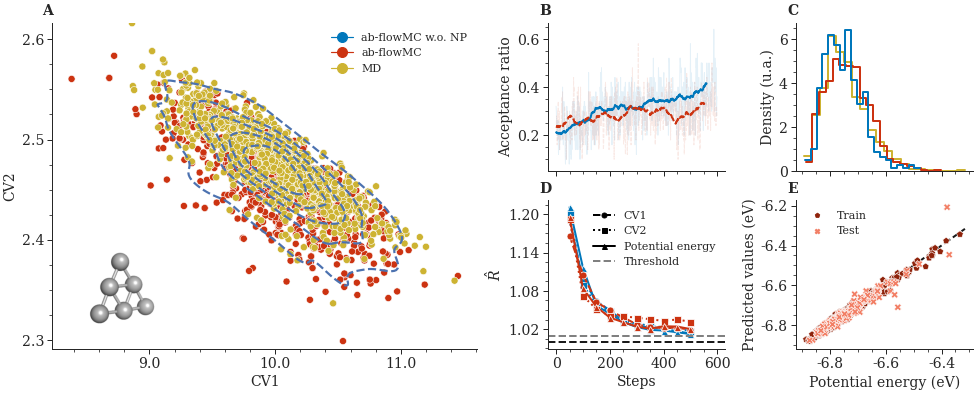

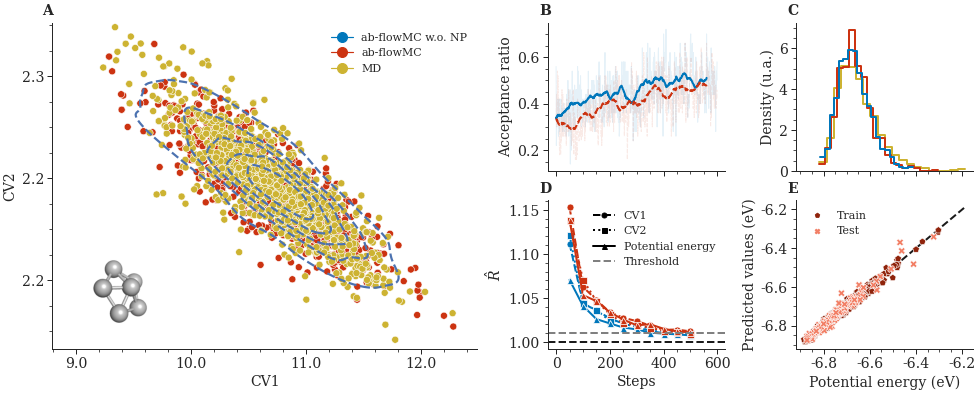

In [22]:
for i in cvs_energy_is.keys():
    set_plot_figure_1(cvs=cvs_energy_is_rand[i][['CV1', 'CV2', 'Method']],
                density_samples=cvs_energy_is_rand[i][cvs_energy_is_rand[i]['Method']==list(methods_color.keys())[0]],
                #density_samples_is[i][
                #    density_samples_is[i]['Method']==list(methods_color.keys())[1]
                #    ],
                accs=accs_is[i],
                rhat=rhats_is[i],
                energies=cvs_energy_is_rand[i][['Potential energy', 'Method']],
                np_predictions=np_predictions[i],
                isomer=i, 
                colors=methods_color)
    
    plt.savefig(path_to_save_figures+'figure_1_is{:d}.png'.format(i), 
            dpi=300, 
            facecolor='white',
            transparent=False)

# Figure 2

In [49]:
cvs_energy_mcmc = pd.read_csv(
    project_path + '/' + data_path + '/cvs_energy_is_ab-flowMM.csv'
                )

density_samples_mcmc = pd.read_csv(
    project_path + '/' + data_path + '/density_samples_ab-flowMM.csv'    
)

isomers_mcmc = pd.read_csv(
        project_path + '/' + data_path + '/isomers_ab-flowMM.csv'    
)

In [50]:
rhats_mcmc = {}

for method in ['ab-flowMM w.o. NP', 'ab-flowMM']:
        
    cvs = cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == method
                        ][['CV1', 'CV2', 'Potential energy']].to_numpy()

    cvs = cvs.reshape(3500, 20, 3)
    
    rhat = R_hat(cvs.transpose(1, 0, 2), labels=['CV1', 'CV2', 'Potential energy'])
    rhats_mcmc[method] = rhat

In [51]:
isomers = isomers_mcmc[isomers_mcmc['Method']=='ab-flowMM'][[str(i) for i in range(20)]].to_numpy()

x = np.arange(0, isomers.shape[0])
y = np.arange(0, isomers.shape[1])

z = isomers.T
horzSum = np.sum(z, 1)
index_sort = np.argsort(horzSum)

z = z[index_sort, :]
horzSum = horzSum[index_sort]

<ErrorbarContainer object of 3 artists>

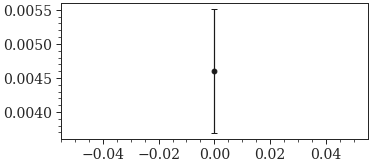

In [61]:
means = isomers[500:].T.reshape(6000, 10).mean(axis=0)
stds = isomers[500:].T.reshape(6000, 10).std(axis=0)

means, stds

# plot means and error bars in one plot

fig, ax = plt.subplots(figsize=(5.5, 2.5))

ax.errorbar(x=0, y=np.mean(means), yerr=np.std(means), fmt='o', color='k', capsize=3)

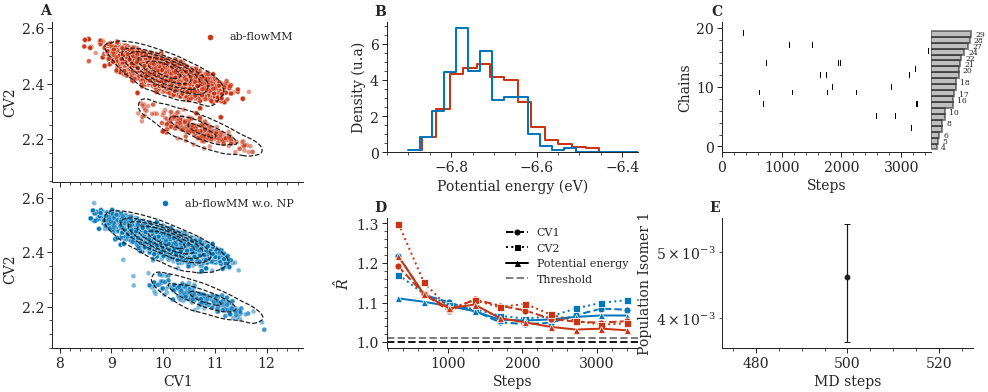

In [66]:
figsize=(5.5*3, 2*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=11
linewidth=2
markersize=5
hspace=0.5
wspace=0.5

ncols = 4
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })   

# -- set figure --

fig, axs = plt.subplots(ncols=ncols, 
                nrows=nrows, 
                figsize=figsize,
                gridspec_kw={'width_ratios': [1.5, 1.5, 0.75, 0.25],
                'height_ratios': [1, 1],
                'wspace': wspace,
                'hspace': hspace}
                )
 
# -- set subplots --

# -- cvs subplots --

ax1 = axs[0][0]
ax4 = axs[1][0]

axs_scatter = [ax1, ax4]

# -- energies and isomers subplots --

ax2 = axs[0][1]

ax3 = axs[0][2]
ax_small = axs[0][3]

# -- rhats and populations subplots --

ax5 = axs[1][1]

gs_ax = axs[1][2].get_gridspec()
axs[1][2].remove()
axs[1][3].remove()

ax6 = fig.add_subplot(gs_ax[1, 2:])

# -- item to subplot and delete top and right axis lines --

posx = -0.05
posy = 1.05

for n, ax in enumerate([ax1, ax2, ax3, ax5, ax6]):
    
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

ax4.spines[['right', 'top']].set_visible(False)
ax_small.spines[['left', 'right', 'top']].set_visible(False)

# -- sharing axis subplots --

ax4.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

ax3.sharey(ax_small)

# -- update positions --

    # -- updating cvs plot size -- 

diff = ax1.get_position().get_points()[0][1] - ax4.get_position().get_points()[1][1]

ax1.set_position(Bbox(ax1.get_position().get_points() - np.array([[0, 1], [0, 0]])*(diff/2)*0.9))
ax4.set_position(Bbox(ax4.get_position().get_points() + np.array([[0, 0], [0, 1]])*(diff/2)*0.9))

    # -- updating isomers plot size --

update_position = ax3.get_position().get_points()
update_position[1][0] = ax_small.get_position().xmin*1
ax3.set_position(Bbox(update_position))

# -- plot cvs (density) --

sns.kdeplot(density_samples_mcmc[ 
    density_samples_mcmc['Method'] == 'ab-flowMM'
    ],
    x='CV1',
    y='CV2',
    color='k',
    linestyles='--',
    linewidth=linewidth,
    levels=6,
    ax=ax1
    )

sns.scatterplot(
    data=cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == 'ab-flowMM' ], 
    x='CV1', 
    y='CV2',
    hue='Method',
    linewidths=linewidth,
    palette=methods_color,
    ax=ax1,
    legend=True,
    alpha=0.5,
    )

ax1.legend(loc='upper right')

sns.kdeplot(density_samples_mcmc[ 
    density_samples_mcmc['Method'] == 'ab-flowMM w.o. NP'
    ],
    x='CV1',
    y='CV2',
    color='k',
    linestyles='--',
    linewidth=linewidth,
    levels=6,
    ax=ax4
    )

sns.scatterplot(
    data=cvs_energy_mcmc[ cvs_energy_mcmc['Method'] == 'ab-flowMM w.o. NP' ], 
    x='CV1', 
    y='CV2',
    hue='Method', 
    linewidths=linewidth,
    palette=methods_color,
    ax=ax4,
    legend=True,
    alpha=0.5,
    )

ax4.legend(loc='upper right')

# -- plot energy --

sns.histplot(data=cvs_energy_mcmc,
            stat='density',
            x='Potential energy',
            hue='Method',
            bins=20,
            alpha=1,
            palette=methods_color,
            element='step',
            linewidth=linewidth,
            fill=False,
            ax=ax2, 
            common_bins=False, 
            common_norm=False,
            legend=False, 
            )

ax2.set_xlim(cvs_energy_mcmc['Potential energy'].min()-0.05, 
             cvs_energy_mcmc['Potential energy'].max()-0.1)

ax2.set_xlabel('Potential energy (eV)')
ax2.set_ylabel('Density (u.a)')

# -- plot rhats --

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']

for key in rhats_mcmc.keys():
    for i in range(rhats_mcmc[key][0].shape[-1]):
        sns.lineplot(x=rhats_mcmc[key][1], 
                    y=rhats_mcmc[key][0][:, i], 
                    linestyle=linestyles[i], 
                    marker=markers[i],
                    markersize=markersize*1.4,
                    linewidth=linewidth,
                    color=methods_color[key], 
                    label=rhats_mcmc[key][2][i],
                    ax=ax5,
                    legend=False)

ax5.axhline(1, c='k', ls='--', 
                  linewidth=linewidth)
ax5.axhline(1.01, c='grey', ls='--', 
              linewidth=linewidth)
ax5.set_xlabel('Steps')
ax5.set_ylabel(r'$\hat{R}$')

# -- plot rhat legend --
        
patches = [ ax5.plot([],[], 
                           marker=markers[i], 
                           linestyle=linestyles[i], 
                           linewidth=linewidth, 
                           markersize=markersize, 
                           color='black', 
            label="{:s}".format(rhats_mcmc[key][2][i]) )[0]  for i in range(len(rhats_mcmc[key][2])) ]

patches = patches + [ ax5.plot([],[],
                            linestyle='dashed', 
                            linewidth=linewidth, 
                            color='gray', 
                label="{:s}".format('Threshold') )[0] ]

ax5.legend(handles=patches)

# -- plot isomers --

ax3.imshow(z, 
           aspect='auto', 
           cmap='gray_r', 
           interpolation='none')

ax_small.barh(np.array(range(len(horzSum))), 
        horzSum, 
        1, 
        color='gray', 
        edgecolor='k', 
        linewidth=linewidth, 
        alpha=0.5)

values, indexes, counts = np.unique(horzSum, return_index=True, return_counts=True)
counts[counts == 1] = 0

for index, value, count in zip(indexes, values, counts):
    ax_small.text(value + 3, 
                index - 0.5 + count/2,
                str(int(value)), 
                fontsize=size_legend*0.7)

ax3.set_ylim(-1, len(z)+1)
  
ax3.set_xlabel('Steps')
ax3.set_ylabel('Chains')

ax_small.set_axis_off()

# -- plot populations --

ax6.errorbar(x=500, y=np.mean(means), yerr=np.std(means), fmt='o', color='k', capsize=3)

ax6.set_ylabel('Population Isomer 1')
ax6.set_xlabel('MD steps')

ax6.set_yscale('log')